In [9]:
# Step 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

In [10]:
# Step 2: Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [11]:
# Step 3: Initial Cleaning
print("Missing values:\n", df.isnull().sum())

# Convert TotalCharges to numeric safely
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with 0 (safe assignment)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID column
df = df.drop('customerID', axis=1)

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
# Step 4: Target Encoding
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
print("Churn value counts:\n", df['Churn'].value_counts(normalize=True))

Churn value counts:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


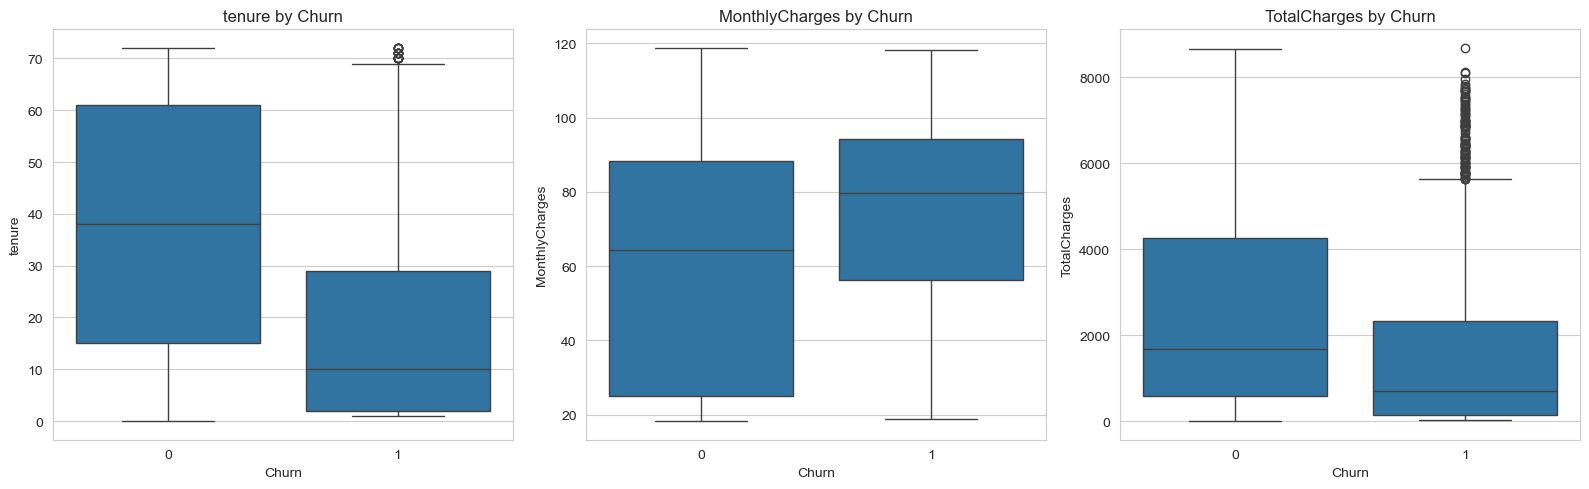

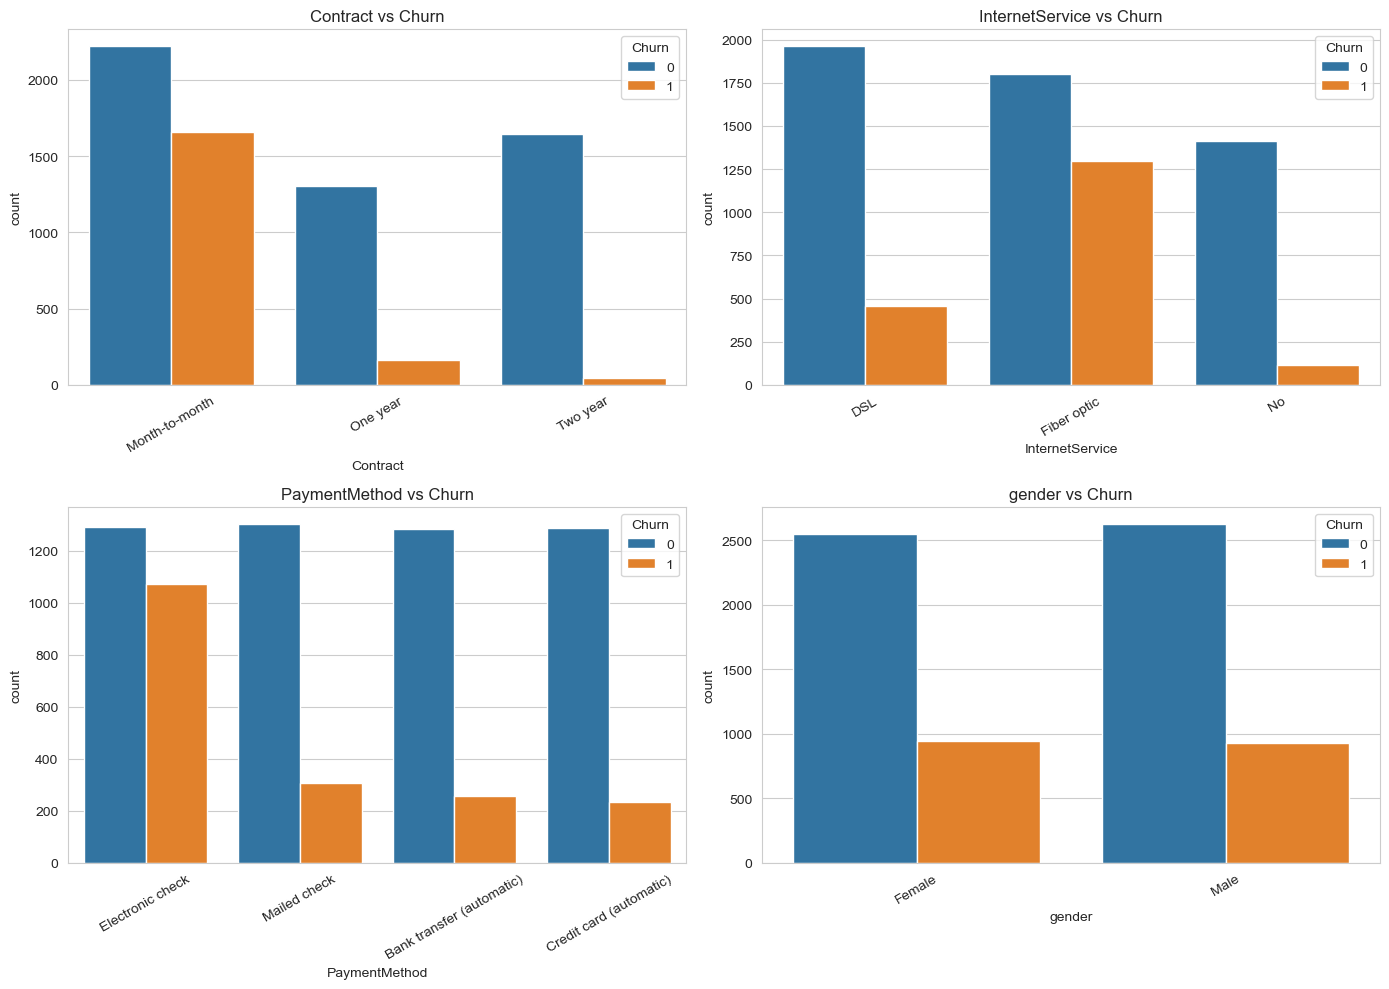

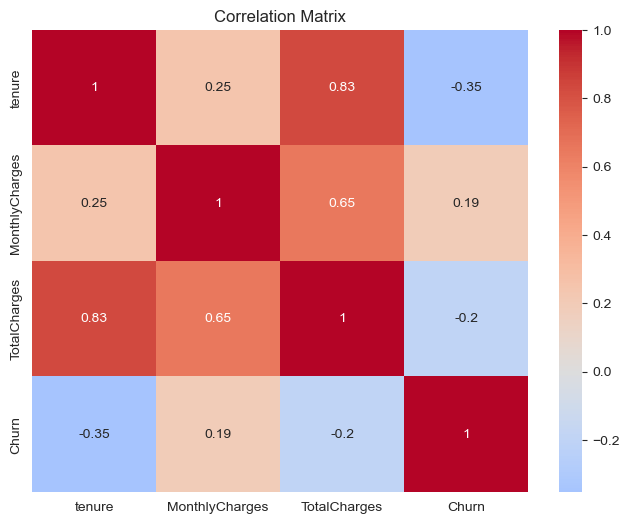

In [13]:

# Step 5: Exploratory Data Analysis (EDA)
# (a) Numeric features vs Churn
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']

# Ensure numeric columns are numeric
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1,3,figsize=(16,5))
for i,col in enumerate(numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

# (b) Categorical features vs Churn
cat_cols = ['Contract','InternetService','PaymentMethod','gender']
fig, axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()
for i,col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# (c) Correlation Heatmap
plt.figure(figsize=(8,6))
corr = df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [14]:
# Step 6: Handle Categorical Variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.append('SeniorCitizen')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (7043, 31)


In [15]:
# Step 7: Split Data
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("Final feature set shape:", X.shape)
print("Feature columns:", X.columns.tolist())

Final feature set shape: (7043, 30)
Feature columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'SeniorCitizen_1']
